# 02. Feature Engineering — Day 1 전략의 피처 설계 구현

Day 1 보고서 **5.1 Feature Engineering / 5.3 데이터 처리** 를 코드로 구현하고, 보조 후보 채택 여부를 **B1 교차검증으로만** 결정함

| Day 1 보고서 약속 | 이 노트북 위치 |
|---|---|
| 정제 규칙 (수명 없는 셀·노이즈 채널 제외, 중도 종료 셀 표시) | 1 |
| 피처 구성 (w5_ / w100_, ΔQ 통계, 용량·충전·온도·저항) | 2 |
| 핵심 = ΔQ_100-10 분산, 보조 후보 = 첨도·전환 시점 → **B1 CV 에서 개선될 때만 추가** | 4 |
| 한계 대응 : **B1 내부 신호만으로 고른 피처 세트** 준비 (누수 점검용) | 5 |
| **5사이클 기준선** 피처 준비 (원논문과 같은 관측 기간) | 6 |

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.preprocess import load_raw, clean, build_meta, ROOT
from src.features import (build_feature_table, FEATURE_SETS, CORE, AUX_CANDIDATES, W5_BASELINE,
                          CANDIDATES_21, select_b1_only)
from src.train import split_b1, cv_evaluate, RegThreshold, SIMPLER_MARGIN, GROUP

pd.set_option('display.width', 200)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
FIG = ROOT / 'results' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

## 1. 데이터 정제 (Day 1 보고서 [표 1])

In [2]:
raw = load_raw()
meta_all = build_meta(raw)
cells, meta = clean(raw)

summary = meta_all.groupby('batch').agg(원본=('cell', 'size'), 제외=('excluded', 'sum')).join(
    meta.groupby('batch').agg(분석대상=('cell', 'size'), Long=('label', 'sum'),
                              중도종료=('censored', 'sum')))
summary['Short'] = summary['분석대상'] - summary['Long']
display(summary)
print('제외 셀 :', meta_all.loc[meta_all.excluded, 'cell'].tolist())

캐시 로드 : data/interim/cells.pkl


,원본,제외,분석대상,Long,중도종료,Short
batch,,,,,,
B1,46,0,46,45,10,1
B2,47,8,39,9,0,30
B3,46,6,40,39,0,1


제외 셀 : ['B2c22', 'B2c23', 'B2c35', 'B2c36', 'B2c37', 'B2c38', 'B2c39', 'B2c40', 'B3c2', 'B3c23', 'B3c32', 'B3c37', 'B3c42', 'B3c43']


- B1 46 / B2 39 / B3 40 셀 → Day 1 보고서와 동일
- 중도 종료 10셀(B1)은 라벨 평가에는 쓰고, **수명 회귀 학습에서는 제외** (`RegThreshold.fit` 에서 처리)

## 2. 피처 생성 (Day 1 보고서 [표 2])

- 같은 정의를 **사이클 1~5 (`w5_`)** 와 **사이클 1~100 (`w100_`)** 두 기간으로 계산
- 충전 프로토콜 `C1(Q1%)-C2` 분해 : `C1` 1단계 전류, `switch_soc` 2단계 전환 시점(SOC %), `C2` 2단계 전류, `Cavg` 0→80% 평균 C-rate
- 내부 저항이 0 으로 기록된 셀(B2 6셀, 초기 사이클 미측정)은 결측으로 처리 → 학습 시 **B1 학습 데이터 중앙값**으로 대체

In [3]:
feat = build_feature_table(cells, meta)
out_dir = ROOT / 'data' / 'processed'
out_dir.mkdir(parents=True, exist_ok=True)
feat.drop(columns=['last_QD']).to_csv(out_dir / 'features.csv', index=False)
print(feat.shape, '→ data/processed/features.csv 저장')
na = feat[CANDIDATES_21 + ['switch_soc']].isna().sum()
print('결측 :', na[na > 0].to_dict())
feat[['cell', 'batch', 'cycle_life', 'label'] + CORE + AUX_CANDIDATES].head()

(125, 42) → data/processed/features.csv 저장
결측 : {'IR2': 6, 'w5_IR_min': 6}


,cell,batch,cycle_life,label,w100_dQ_logvar,w100_dQ_kurt,switch_soc
0,B1c0,B1,1190,1,-5.051527,-0.909997,80.0
1,B1c1,B1,1179,1,-5.135776,-1.038547,80.0
2,B1c2,B1,1177,1,-4.951883,-1.173739,80.0
3,B1c3,B1,1226,1,-4.386348,-1.124219,80.0
4,B1c4,B1,1227,1,-4.604779,-1.361164,80.0


## 3. 후보 풀 — Day 1 EDA 결론 재확인

Day 1 Q5 : 세 배치에서 수명과의 상관 방향이 같은 피처만 후보로 둠 → 핵심 `w100_dQ_logvar`, 보조 `w100_dQ_kurt`, `switch_soc`
(아래 표는 Day 1 결과의 재현이며, **최종 조합은 4 에서 B1 학습 데이터로만 결정**)

In [4]:
rows = []
for c in ['w100_dQ_logvar', 'w100_dQ_mean', 'w100_dQ_logmin', 'w100_dQ_kurt', 'switch_soc',
          'w5_chargetime', 'Cavg', 'C1', 'IR2', 'w100_fade_slope', 'w5_dQ_logvar']:
    r = {'feature': c}
    for b in ['B1', 'B2', 'B3']:
        sub = feat[feat.batch == b]
        r[b] = stats.spearmanr(sub[c], sub['log_life'], nan_policy='omit').correlation
    r['방향 일치'] = len({np.sign(r[b]) for b in ['B1', 'B2', 'B3']}) == 1
    rows.append(r)
pool = pd.DataFrame(rows).set_index('feature').round(2)
display(pool)
print('ΔQ 계열 상관 (중복 확인) :')
display(feat[['w100_dQ_logvar', 'w100_dQ_mean', 'w100_dQ_logmin', 'w100_dQ_kurt', 'switch_soc']].corr('spearman').round(2))

,B1,B2,B3,방향 일치
feature,,,,
w100_dQ_logvar,-0.85,-0.72,-0.76,True
w100_dQ_mean,0.83,0.72,0.72,True
w100_dQ_logmin,-0.77,-0.70,-0.76,True
w100_dQ_kurt,0.31,0.49,0.15,True
switch_soc,0.19,0.29,0.41,True
w5_chargetime,0.63,-0.83,0.06,False
Cavg,-0.63,0.32,-0.16,False
C1,-0.48,0.06,-0.16,False
IR2,0.20,-0.33,0.18,False


ΔQ 계열 상관 (중복 확인) :


,w100_dQ_logvar,w100_dQ_mean,w100_dQ_logmin,w100_dQ_kurt,switch_soc
w100_dQ_logvar,1.00,-0.99,0.98,-0.38,-0.18
w100_dQ_mean,-0.99,1.00,-0.97,0.35,0.18
w100_dQ_logmin,0.98,-0.97,1.00,-0.30,-0.22
w100_dQ_kurt,-0.38,0.35,-0.30,1.00,-0.05
switch_soc,-0.18,0.18,-0.22,-0.05,1.00


## 4. 피처 세트 선택 — B1 학습 구간 GroupKFold CV

- B1 을 **충전 방식 단위**로 학습(80%) / Hold-out(20%) 으로 나누고, 학습 구간에서만 5-fold GroupKFold 를 돌림
- 모델 : ElasticNet (log10 수명), 하이퍼파라미터는 각 fold 학습 데이터 안의 내부 GroupKFold 로 선택
- 선택 기준 : **CV 수명 오차(MAPE) 최소**, 단 차이가 0.5%p 미만이면 **피처 수가 적은 쪽** (Day 1 "B1 CV 에서 개선될 때만 추가")
- 분류 지표가 아닌 MAPE 로 고르는 이유 : B1 학습 구간의 Short 가 1개라 fold 별 F1·Accuracy 가 거의 같음 (변별력 없음)

B1 학습 구간 : 35셀 (Short 1, 중도 종료 7) / 충전 방식 18종
B1 Hold-out : 11셀 (Short 0, 중도 종료 3) / 충전 방식 ['3.6C(80%)-3.6C', '5.4C(60%)-3C', '5.4C(70%)-3C', '6C(50%)-3C', '7C(30%)-3.6C']


,feature_set,features,n,cv_mape,cv_mape_std,cv_spearman,fold_mape
0,core,w100_dQ_logvar,1,7.67,2.88,0.67,"[5.0, 10.3, 10.9, 4.8, 7.4]"
1,core+kurt,"w100_dQ_logvar, w100_dQ_kurt",2,8.01,2.52,0.67,"[4.9, 10.0, 10.7, 6.0, 8.5]"
2,core+switch,"w100_dQ_logvar, switch_soc",2,8.17,3.15,0.76,"[4.8, 12.2, 10.6, 5.9, 7.3]"
3,core+kurt+switch,"w100_dQ_logvar, w100_dQ_kurt, switch_soc",3,56.66,110.01,0.76,"[4.9, 253.4, 10.6, 6.0, 8.5]"


→ 선택 : core  ['w100_dQ_logvar']


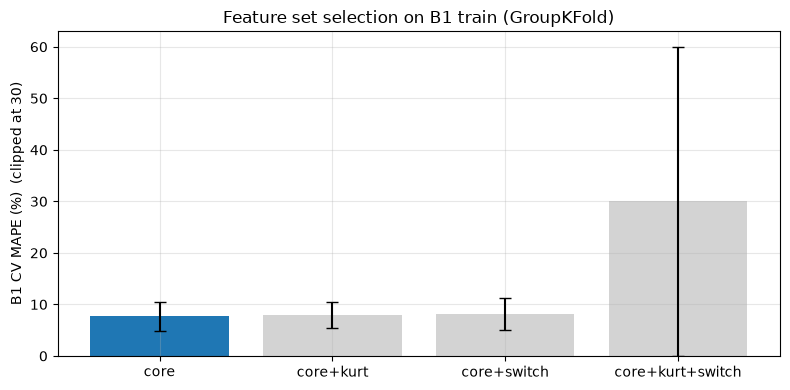

In [5]:
b1_tr, b1_ho = split_b1(feat)
print(f'B1 학습 구간 : {len(b1_tr)}셀 (Short {int((b1_tr.label == 0).sum())}, 중도 종료 {int(b1_tr.censored.sum())}) / '
      f'충전 방식 {b1_tr[GROUP].nunique()}종')
print(f'B1 Hold-out : {len(b1_ho)}셀 (Short {int((b1_ho.label == 0).sum())}, 중도 종료 {int(b1_ho.censored.sum())}) / '
      f'충전 방식 {sorted(b1_ho[GROUP].unique())}')

sel = []
for name, fs in FEATURE_SETS.items():
    f = cv_evaluate(lambda fs=fs: RegThreshold('elasticnet', fs), b1_tr)
    sel.append(dict(feature_set=name, features=', '.join(fs), n=len(fs),
                    cv_mape=f['mape'].mean(), cv_mape_std=f['mape'].std(), cv_spearman=f['spearman'].mean(),
                    fold_mape=np.round(f['mape'].values, 1).tolist()))
sel = pd.DataFrame(sel)
best = sel['cv_mape'].min()
chosen = sel[sel['cv_mape'] - best < SIMPLER_MARGIN].sort_values(['n', 'cv_mape']).iloc[0]['feature_set']
display(sel.round(2))
print(f'→ 선택 : {chosen}  {FEATURE_SETS[chosen]}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sel['feature_set'], sel['cv_mape'].clip(upper=30), yerr=sel['cv_mape_std'].clip(upper=30),
       color=['tab:blue' if n == chosen else 'lightgray' for n in sel['feature_set']], capsize=4)
ax.set(ylabel='B1 CV MAPE (%)  (clipped at 30)', title='Feature set selection on B1 train (GroupKFold)')
plt.tight_layout(); plt.savefig(FIG / 'feature_set_selection.png', dpi=120); plt.show()

**결과 해석**
- 핵심 피처 하나(`core`)가 B1 CV 수명 오차가 가장 작음. 첨도·전환 시점을 더해도 오차가 줄지 않음
- 세 개를 모두 넣으면 한 fold 에서 오차가 크게 튐 → 학습 셀이 적을 때 피처를 늘리면 불안정해진다는 Day 1 판단(소표본·최소 피처)과 일치
- 따라서 Day 1 계획대로 **보조 후보는 채택하지 않고 ΔQ_100-10 분산 하나로 최종 피처를 확정** — 결정은 B1 학습 데이터만으로 이루어짐

## 5. 누수 점검용 "B1 단독 선별" 세트 (Day 1 보고서 Q5 한계 · 5.5)

- Day 1 의 후보 축소는 테스트 배치(B2·B3)의 상관 방향을 참고했다는 한계가 있음
- 비교용으로 **B1 학습 데이터만 보고** 21개 후보 중 |상관| 상위 피처를 고르고(상관 0.9 초과 중복은 제외), 같은 파이프라인으로 성능을 비교함 (03 노트북)

In [6]:
b1_only, b1_rho = select_b1_only(b1_tr)
print('B1 단독 선별 세트 :', b1_only)
display(b1_rho.head(10).round(2).to_frame('B1 학습 구간 Spearman(피처, log 수명)'))
f = cv_evaluate(lambda: RegThreshold('elasticnet', b1_only), b1_tr)
print(f"B1 CV MAPE : {f['mape'].mean():.2f}%  (core : {sel.set_index('feature_set').loc['core', 'cv_mape']:.2f}%)")

B1 단독 선별 세트 : ['w100_dQ_logvar', 'w100_dQ_logmin', 'w100_fade_slope', 'Cavg']


,"B1 학습 구간 Spearman(피처, log 수명)"
w100_dQ_logvar,-0.85
w100_dQ_mean,0.85
w100_dQ_logmin,-0.74
w100_fade_slope,0.63
w100_QDmax_m_QD2,0.59
Cavg,-0.58
w5_chargetime,0.58
w100_dQ_skew,-0.56
w5_dQ_mean,0.47
C1,-0.40


B1 CV MAPE : 10.17%  (core : 7.67%)


- B1 만 보면 Day 1 에서 "배치 간 방향이 뒤집힌다"고 판단한 **열화 기울기·평균 충전 속도**가 상위에 들어옴
- 그런데 이 세트는 **B1 CV 에서도** 핵심 피처 하나보다 오차가 큼 → 최종 피처 선택(`core`)은 테스트 배치 정보 없이 B1 만으로도 정당화됨

## 6. 5사이클 기준선 피처 (Day 1 보고서 5.2 트레이드오프)

원논문 분류 모델과 같은 관측 기간(사이클 1~5)의 피처 : ΔQ_5-4 분산·최솟값, 사이클 2 용량, 최대−사이클 2 용량, 충전 시간, 평균 온도, 최소 내부 저항

In [7]:
print(W5_BASELINE)
f = cv_evaluate(lambda: RegThreshold('elasticnet', W5_BASELINE), b1_tr)
print(f"5사이클 기준선 B1 CV MAPE : {f['mape'].mean():.2f}%")

['w5_dQ_logvar', 'w5_dQ_logmin', 'QD2', 'w5_QDmax_m_QD2', 'w5_chargetime', 'w5_Tavg', 'w5_IR_min']


5사이클 기준선 B1 CV MAPE : 19.62%


## 7. 최종 피처 설계 요약

| 구분 | 피처 | 근거 |
|---|---|---|
| **최종** | `w100_dQ_logvar` (ΔQ_100-10 분산, log) | Day 1 : 세 배치 공통 강한 상관 / Day 2 : B1 CV 수명 오차 최소 |
| 검토 후 미채택 | `w100_dQ_kurt`, `switch_soc` | B1 CV 에서 개선 없음 (Day 1 "개선될 때만 추가" 규칙) |
| 비교용 | B1 단독 선별 세트 | 누수 점검 — B1 CV 에서도 열세 |
| 비교용 | 5사이클 기준선 | 원논문과 같은 관측 기간 비교 |
| 처리 | 결측 IR → B1 중앙값, 표준화 → B1 으로만 fit, 중도 종료 셀 → 회귀 학습 제외 | 누수 방지, 하한값 수명 배제 |